# Aufwand von Algorithmen

## Aufwand eines Algorithmus

*  wichtige Kenngröße für Algorithmen
      *  um Algorithmen zu bewerten / vergleichen
*  __Aufwand = Anzahl benötigter Operationen__
      *  Zuweisungen
      *  Vergleiche
      *  arithmetische Operationen
*  programmspezifische Operationen nicht gezählt
      *  Deklarationen \& Initialisierungen
      *  Schleifen, Verzweigungen etc.
      *  Zählvariablen in Schleifen
*  Aufwand wird durch "`einfaches"' Zählen ermittelt
*  __Konventionen zum Zählen nicht einheitlich__
*  in EPROG ist Aufwand für __worst case__ interessant
      *  d.h. maximaler Aufwand im schlechtesten Fall
*  häufig ist auch "mittlerer Aufwand" interessant
(d.h. Erwartungswert des Aufwands)
      *  mathematisch komplizierter
      *  deshalb nicht in EPROG
*  in EPROG (maximal) benötigte Formeln:

$$ 
\sum_{j=1}^n 1 = n,
\quad\quad
\sum_{j=1}^n j = \frac{n(n+1)}{2},
\quad\quad
\sum_{j=1}^n j^2 = \frac{n(n+1)(2n+1)}{6}
$$


## Beispiel: Maximum suchen

*  Beim Zählen wird jede Schleife zu einer Summe!
      *  d.h. `for` in Zeile 3 ist $\sum_{i=1}^{n-1}$
      * $n$ = Länge des Arrays

*  Aufwand:
      *   1 Zuweisung in Zeile 2
      *  In jedem Schritt der `for`-Schleife $\rightsquigarrow$ Zeile 3-6
            *  1 Zuweisung in Zeile 4
            *  1 Vergleich in Zeile 5
            *  ggf. 1 Zuweisung in Zeile 6 (im worst case immer)
     

*  insgesamt Operationen 

$$ 
1 + \sum_{i=1}^{n-1} 3 = 1+3(n-1)=3n-2
$$

*  wobei Zählvariable nicht in Aufwand eingeht, d.h. nur Statement der `for`-Schleife wird berücksichtigt



In [1]:
def mymax(arr):
    max_val = arr[0]
    for i in range(1, len(arr)):
        val = arr[i]
        if val > max_val:
            max_val = val
    return max_val

## Landau-Symbol $\mathcal{O}$ (= groß-O)

*  oft nur __Größenordnung__ des Aufwands interessant
*   Schreibweise $ f=\mathcal{O}(g)$ für $ x\to x_0$
      *  heißt $\displaystyle\limsup_{x\rightarrow x_0}\Bigg|\frac{f(x)}{g(x)}\Bigg|<\infty$
      *  d.h. es existiert eine Konstante $C > 0$ mit 
      *  $|f(x)| \le C\,|g(x)|$ für $x\to x_0$.

      *  d.h. $f$ wächst höchstens so schnell wie $g$ für $x\to x_0$



*  Beispiel: Maximum suchen
      *  Aufwand $2n-1=\mathcal{O}(n)$ für $n\rightarrow\infty$<



*  häufig entfällt "für $ x\to x_0$"
      *  dann Grenzwert $x_0$ kanonisch z.B. $2n-1 = \mathcal{O}(n)$



*  Sprechweise (nur Beispiele):
      *  Algorithmus hat __linearen Aufwand__,
falls Aufwand $\mathcal{O}(n)$ bei Problemgröße $n$
       *  Maximumssuche hat linearen Aufwand
      *  Algorithmus hat __fastlinearen Aufwand__,
falls Aufwand $\mathcal{O}(n\log n)$ bei Problemgröße $n$
      *  Algorithmus hat __quadratischen Aufwand__,
falls Aufwand $\mathcal{O}(n^2)$ bei Problemgröße $n$
      *  Algorithmus hat __kubischen Aufwand__,
falls Aufwand $\mathcal{O}(n^3)$ bei Problemgröße $n$
      *  Algorithmus hat __exponentiellen Aufwand__,
falls Aufwand $\mathcal{O}(2^n)$ bei Problemgröße $n$


## Suchen im Vektor

*  Aufgabe:
     *  Suche Index $j$ mit `vector[j] = value`
     *  Rückgabe $-1$, falls solcher nicht existiert
*  in jedem Schritt der $j$-Schleife
     *  $1$ Vergleich

*  Gesamtanzahl der Operationen

$$
\sum_{j=0}^{n-1} 1 = n
$$

*  Aufwand $\mathcal{O}(n)$ im worst case

In [1]:
def search(vector, target):
    for i in range(len(vector)):
        if vector[i] == target:
            return i
    return -1


## Binäre Suche im sortierten Vektor

*  __Voraussetzung: Vektor ist aufsteigend sortiert__
*  Modifiziere Idee des Bisektionsverfahrens
      *  d.h. natürliche Suche im Telefonbuch
      *  Betrachte halben Vektor, falls $ vector[j]\neq value$

*  __Frage:__ Wieviele Iterationen hat der Algorithmus?
      *  jeder Schritt halbiert Vektor
      *  Falls $n$ Zweierpotenz, gilt $n/2^k = 1$ 
      *  dann maximal $1 + \log_2 n$ Schritte
      * in jedem Schritt: 2 Vergl. + 2 Zuw. + 1 Division + 3 Add./Subtr.

*  Aufwand $\mathcal{O}(\log_2n)$, d.h. logarithmischer Aufwand
      *  sog. sublinearer Aufwand $\mathcal{O}(\log_2n) \ll \mathcal{O}(n)$

In [2]:
def binsearch(vector, target):
    low = 0
    high = len(vector) - 1
    while low <= high:
        mid = (low + high) // 2
        if vector[mid] == target:
            return mid
        elif vector[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1

## Minsort


*  In jedem Schritt der $i$-Schleife
      * $1$ Zuweisung
      * $j$-Schleife von $i+1$ bis $n-1$
        * $1$ Vergleich
        * ggf. $1$ Zuweisung (worst case!)
        * Vertauschung: 3 Zuweisungen (Dreieckstausch)

*  quadratischer Aufwand $\mathcal{O}(n^2)$, weil: 

$$
\sum_{i=0}^{n-1} \Big(1 + \sum_{j=i+1}^{n-1}5\Big)
= n-1+\sum_{i=0}^{n-1}5\big(n-(i+1)\big)
= n-1+5\sum_{i=1}^{n}i
= n-1+5\,\frac{n(n-1)}2
$$

In [3]:
def minsort(vector):
    for i in range(len(vector)):
        # Find the minimum element in the unsorted portion of the array
        min_idx = i
        for j in range(i+1, len(vector)):
            if vector[j] < vector[min_idx]:
                min_idx = j
        # Swap the found minimum element with the first element of the unsorted portion
        vector[i], vector[min_idx] = vector[min_idx], vector[i]

## Aufwand & Rechenzeit

- Jede Operation kostet Rechenzeit
  - d.h. Aufwand korrespondiert zu Rechenzeit 

- __Frage:__ Welche Rechenzeit kann ich erwarten?
  - Antwort kann nur eine relative Größe sein, da Rechner unterschiedlich schnell

- theoretische Voraussagen
  - __linearer Aufwand__
    - Problemgröße $n$ $\rightarrow$ $Cn$ Operationen
    - Problemgröße $kn$ $\rightarrow$ $Ckn$ Operationen
    - d.h. $3\times$ Problemgröße $\rightarrow$ $3\times$ Rechenzeit
  - __quadratischer Aufwand__
    - Problemgröße $n$ $\rightarrow$ $Cn^2$ Operationen
    - Problemgröße $kn$ $\rightarrow$ $Ck^2n^2$ Operationen
    - d.h. $3\times$ Problemgröße $\rightarrow$ $9\times$ Rechenzeit
  - etc.

- BSP. Code braucht $1$ Sekunde für $n=1000$
  - Aufwand $\mathcal{O}(n)$ $\rightarrow$ $10$ Sekunden für $n=10000$ 
  - Aufwand $\mathcal{O}(n^2)$ $\rightarrow$ $100$ Sekunden für $n=10000$
  - Aufwand $\mathcal{O}(n^3)$ $\rightarrow$ $1000$ Sek. für $n=10000$



## Zeitmessung

 *  Wozu Zeitmessung?
       *  Vergleich von Algorithmen / Implementierungen
       *  Überprüfen theoretischer Voraussagen
 *  Modul `time`
      * `time.time()` liefert aktuelle Zeit in Sekunden seit 1.1.1970
      * `start = time.time()` vor Code
      * `end = time.time()` nach Code
      


### Beispiel: Zeitmessung
- Um Aufwand zu vergleichen macht es Sinn die Zeit für große $n$ zu messen
- Zum Beispiel $n=2^k$ für $k=1,2,\ldots$


In [7]:
import time
N = 28

for n in range(N):
  m = 2**n
  sorted_vec = list(range(m))
  unsorted_vec = sorted_vec[::-1]

  # Measure time for search
  start = time.time()
  search(sorted_vec, m-2)
  end = time.time()
  time_search = end - start
  # Measure time for binsearch
  start = time.time()
  binsearch(sorted_vec, m-2)
  end = time.time()
  time_binsearch = end - start
  # Measure time for minsort
  start = time.time()
  #minsort(unsorted_vec)
  end = time.time()
  time_minsort = end - start

  print(f"n={m:8d} search={time_search:.6f}s binsearch={time_binsearch:.6f}s minsort={time_minsort:.6f}s")

n=       1 search=0.000557s binsearch=0.000003s minsort=0.000000s
n=       2 search=0.000001s binsearch=0.000001s minsort=0.000000s
n=       4 search=0.000001s binsearch=0.000001s minsort=0.000000s
n=       8 search=0.000000s binsearch=0.000000s minsort=0.000000s
n=      16 search=0.000001s binsearch=0.000001s minsort=0.000000s
n=      32 search=0.000001s binsearch=0.000000s minsort=0.000001s
n=      64 search=0.000002s binsearch=0.000000s minsort=0.000000s
n=     128 search=0.000003s binsearch=0.000001s minsort=0.000000s
n=     256 search=0.000006s binsearch=0.000001s minsort=0.000000s
n=     512 search=0.000012s binsearch=0.000001s minsort=0.000000s
n=    1024 search=0.000026s binsearch=0.000001s minsort=0.000001s
n=    2048 search=0.000047s binsearch=0.000001s minsort=0.000000s
n=    4096 search=0.000089s binsearch=0.000001s minsort=0.000000s
n=    8192 search=0.000173s binsearch=0.000002s minsort=0.000000s
n=   16384 search=0.000346s binsearch=0.000002s minsort=0.000000s
n=   32768

__quadratischer Aufwand__ ist deutlich teurer als __linearer Aufwand__

Minsort braucht
- ca. 1 Sekunde für $n= 2^{13}= 8192$
- ca. 4 Sekunden für $n= 2^{14}= 16384$
- ca. 4.5 Stunden für $n= 2^{20}= 1048576$
- ca 34 Jahre für $n = 2^{27}= 134217728$ 

### Beispiel: Aufwand plotten
Um den Aufwand von Algorithmen zu visualisieren eigenen sich logarithmische Plots besonders gut.
- der Exponent des Aufwands (linear =1, quadratisch=2, kubisch=3) ist als Steigung der Linie erkennbar


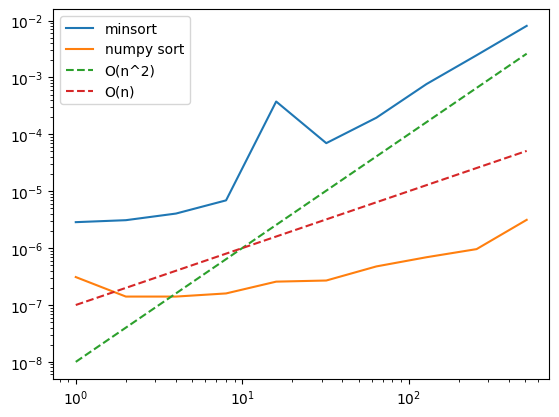

In [12]:
import time
import random as rnd
import matplotlib.pyplot as plt

def minsort(arr):
    n = len(arr)
    for i in range(n):
        min_index = i
        for j in range(i + 1, n):
            if arr[j] < arr[min_index]:
                min_index = j
        arr[i], arr[min_index] = arr[min_index], arr[i]

N = 10
times1 = []
times2 = []
for n in range(N):
    m = 2**n
    data = [rnd.random() for _ in range(m)]
    start = time.time()
    minsort(data)
    end = time.time()
    times1.append(end - start)

    data = [rnd.random() for _ in range(m)]
    start = time.time()
    for _ in range(100):
        data.sort()
    end = time.time()
    times2.append((end - start)/100)

xdata = [2**i for i in range(N)]
plt.loglog(xdata, times1, label='minsort')
plt.loglog(xdata, times2, label='numpy sort')
plt.loglog(xdata, [1e-8*x**2 for x in xdata], label='O(n^2)', linestyle='dashed')
plt.loglog(xdata, [1e-7*x for x in xdata], label='O(n)', linestyle='dashed')
plt.legend()
plt.show()

## Aufwand von vorimplementierten Funktionen
Python liefert viele vorimplementierte Funktionen deren Aufwand nicht immer offensichtlich ist. 
- Um den Aufwand abzuschätzen, ist es oft hilfreich, sich vorzustellen wie die Funktion implementiert sein könnte.

### Beispiel: Listenfunktionen

Die Funktion `list.append(x)` hat z.B. im Durchschnitt einen Aufwand von $\mathcal{O}(1)$, im worst case $\mathcal{O}(n)$, wenn die Liste vergrößert werden muss.
- Python reserviert automatisch mehr Speicher als benötigt, um im Fall von Erweiterungen nicht jedes Mal den gesamten Speicher neu zuordnen zu müssen.
- Wenn dieser zusätzliche Speicher nicht mehr ausreicht, wird eine neue, größere Speicherstelle zugewiesen und der gesamte Inhalt der Liste dorthin kopiert. Dies verursacht den worst-case Aufwand von $\mathcal{O}(n)$.

In [7]:
import time
x = [0]
n = 10**7
max_time = 0 
mean_time = 0
for i in range(n):
    start = time.time()
    x.append(0)
    end = time.time()
    max_time = max(max_time, end-start)
    mean_time += (end-start)
mean_time /= n
print("Mittelwert Zeit für append:", mean_time)
print("Max Zeit für append:", max_time)

Mittelwert Zeit für append: 7.821056842803956e-08
Max Zeit für append: 0.011293172836303711


- Die Funktion `list.insert(i, x)` hat im worst case einen Aufwand von $\mathcal{O}(n)$, da alle Elemente ab Index `i` um eine Position verschoben werden müssen.

In [8]:
n = 10**5
x = [0]*n
start = time.time()
x.insert(0, 1)
end = time.time()
print("Zeit für Einfügen am Anfang:", end-start)

Zeit für Einfügen am Anfang: 0.00012731552124023438


- Das Erstellen einer Liste mit `list(range(n))` oder `x = [0]*n` hat einen Aufwand von $\mathcal{O}(n)$, da `n` Elemente erstellt und in die Liste eingefügt werden müssen.

In [9]:
n = 10**7
start = time.time()
x = [0]*n
end = time.time()
print("Zeit für Erstellen Liste der Länge n:", end-start)

Zeit für Erstellen Liste der Länge n: 0.006880283355712891


### Beispiel: Matrix-Vektor Multiplikation
- Aufwand $\mathcal{O}(n)$ für das Anlegen des Ergebnisvektors in Zeile 2
- Schleife von 1 bis n in Zeile 3
  - Schleife von 1 bis n in Zeile 4
    - 1 Multiplikation und 1 Addition in Zeile 5

- Aufwand für die Schleifen also

$$
\sum_{j=0}^{n-1} \sum_{k=0}^{n-1} 2 = \sum_{j=0}^{n-1} 2n = 2n^2
$$

- Insgesamt also Aufwand $\mathcal{O}(n) + \mathcal{O}(n^2) = \mathcal{O}(n^2)$


In [10]:
def matrix_vector_mult(A, x, n):
    y = [0]*n # Ergebnisvektor  initialisieren
    for j in range(n):
        for k in range(n):
            y[j] += A[j][k] * x[k]
    return y

### Aufwand: Zusammenfassung

*  Quadratischer Aufwand für große $n$ spürbar
*  Fazit: Algorithmen sollen kleinen Aufwand haben
      *  Ziel der numerischen Mathematik
      *  nicht immer möglich, oft offene Frage, z.B., Aufwand für Lösen von LGS, oder ${\rm P}\neq {\rm NP}$ in der Informatik